In [2]:
from datetime import date
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2 
import seaborn as sns

In [3]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [4]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "revision_results/"

annot_path = parent_directory  + "annotations/"

output_path = input_path

figure_path = parent_directory + "revision_figures/"

# Feature Comparison between cell lines

In [5]:
file_U2OS_Median_type = '/*[0-9]_' + 'FMP_U2OS_norm_reduced_filtered_median.csv'
files_U2OS_Median = glob.glob(input_path + file_U2OS_Median_type)

### gets latest file
max_file_U2OS_Median = max(files_U2OS_Median, key=os.path.getctime)

### load file
data_U2OS_Median = pd.read_csv(max_file_U2OS_Median)
data_U2OS_Median.shape

(1350, 628)

In [6]:
file_HepG2_Median_type = '/*[0-9]_' + 'FMP_HepG2_norm_reduced_filtered_median.csv'
files_HepG2_Median = glob.glob(input_path + file_HepG2_Median_type)

### gets latest file
max_file_HepG2_Median = max(files_HepG2_Median, key=os.path.getctime)

### load file
data_HepG2_Median = pd.read_csv(max_file_HepG2_Median)
data_HepG2_Median.shape

(873, 628)

In [7]:
key_col = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"]
U2OS_feature_df = data_U2OS_Median.drop(columns=key_col)

In [8]:
key_col = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"]
HepG2_feature_df = data_HepG2_Median.drop(columns=key_col)

In [9]:
venn_1 = U2OS_feature_df.columns
venn_2 = HepG2_feature_df.columns
venn_3 = list(set(venn_1) & set(venn_2))

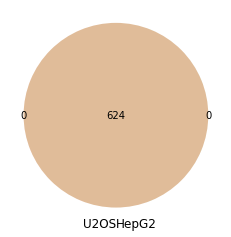

In [10]:

venn2(
    subsets = (len(venn_1) - len(venn_3), 
               len(venn_2) - len(venn_3), 
               len(venn_3)), 
    set_labels = ('U2OS', 'HepG2'))

plt.savefig(figure_path + str(date.today()) + '_FMP_FeatureOverlap.pdf',  dpi=300)
plt.show()

# Compound comparison after filters

In [11]:
venn_1_cpd = data_U2OS_Median["Metadata_EOS"].unique()

In [12]:
venn_2_cpd = data_HepG2_Median["Metadata_EOS"].unique()

In [13]:
venn_3_cpd = list(set(venn_1_cpd) & set(venn_2_cpd ))

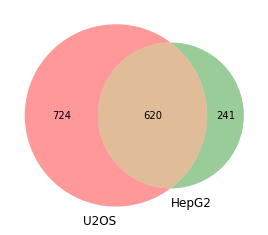

In [14]:
venn2(
    subsets = (len(venn_1_cpd) - len(venn_3_cpd), 
               len(venn_2_cpd) - len(venn_3_cpd), 
               len(venn_3_cpd)), 
    set_labels = ('U2OS', 'HepG2'))

plt.savefig(figure_path + str(date.today()) + '_FMP_CompoundOverlap.pdf',  dpi=300)
plt.show()

# %Pairing

In [15]:
# add a column for cell type
data_U2OS_Median['Metadata_Cell_type'] = 'U2OS'
data_HepG2_Median['Metadata_Cell_type'] = 'HepG2'

# modify Metadata_EOS to include CellType Info
data_U2OS_Median['Metadata_EOS_mod'] = 'U2OS_' + data_U2OS_Median['Metadata_EOS'].astype(str)
data_HepG2_Median['Metadata_EOS_mod'] = 'HepG2_' + data_HepG2_Median['Metadata_EOS'].astype(str)

In [16]:
UTIL.get_featuredata(data_U2OS_Median)

,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_BoundingBoxMinimum_Y,Nuc_AreaShape_Compactness,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MinorAxisLength,Nuc_AreaShape_Orientation,Nuc_AreaShape_Perimeter,Nuc_AreaShape_Zernike_0_0,Nuc_AreaShape_Zernike_1_1,...,Cyto_Texture_InfoMeas2_ER_3_00_256,Cyto_Texture_InfoMeas2_Mito_3_02_256,Cyto_Texture_InverseDifferenceMoment_AGP_5_00_256,Cyto_Texture_InverseDifferenceMoment_DNA_10_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_03_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_DNA_3_00_256
0,-0.654842,0.940644,-1.214050,0.785816,1.230209,-0.147985,0.919382,-1.291901,0.084490,-0.084183,...,5.308864,-0.185362,-10.918224,0.380581,0.901834,-0.156313,-0.027029,-6.895279,-8.010751,-0.633295
1,-1.041602,-0.542081,0.120032,-0.773869,-0.119307,0.460628,-0.215418,0.494088,0.812983,0.027583,...,5.166602,-0.489532,-9.931498,1.164191,2.095741,0.761223,1.731913,-5.340155,-5.854969,-1.668410
2,-1.989842,-0.318624,2.551672,-1.588957,-2.521092,-0.661292,0.247237,-0.064077,-1.690293,0.548846,...,4.225475,0.726053,-7.165480,2.560441,1.898461,1.746517,2.424811,-4.561538,-4.766277,-2.575370
3,-0.608771,-0.719603,-0.586576,-0.010605,0.591338,-0.015408,0.180747,-0.215509,0.279990,0.390246,...,5.538047,1.185807,-8.790047,0.495909,1.420143,0.214650,1.300949,-5.616345,-5.913126,-1.362218
4,-0.312873,-0.940532,-2.341552,1.806998,2.384489,-0.831316,-0.133674,-3.410811,2.080047,1.475419,...,6.748336,1.693292,-16.126016,-0.834670,0.348994,-0.004865,0.672937,-12.007788,-12.898571,-0.815458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,-1.154408,0.217077,-2.597152,1.838084,2.646222,-4.935285,-0.252842,-4.574000,2.335009,-2.027038,...,3.443199,1.333270,-17.444305,-0.186774,-0.504228,-1.033565,-1.360566,-7.458249,-8.749268,-0.229327
1346,-0.318979,-1.479685,-3.649772,1.142472,3.718083,-3.011169,0.194710,-4.030333,2.662289,-1.025668,...,4.196793,1.836452,-23.758109,-0.779351,-0.502939,-1.020524,-0.582878,-7.581201,-9.513997,0.483885
1347,-0.589292,-1.069244,-3.009349,0.926135,3.063894,-3.483561,0.030385,-5.935557,2.453100,0.152311,...,4.827018,1.457177,-19.776712,-0.872124,-0.736734,-0.166548,-0.367597,-8.037041,-11.434007,0.852471
1348,0.177287,-0.012292,-2.797453,1.927819,2.840048,-2.444807,-0.377835,-4.380941,2.721053,-1.294433,...,1.458328,1.966458,-18.572151,-2.346639,-2.130821,-1.427095,-1.982340,-10.618737,-11.466515,1.617136


In [17]:
n_samples = 10000

modality_1_df = data_U2OS_Median
modality_2_df = data_HepG2_Median
modality_1_perturbation = "U2OS"
modality_2_perturbation = "HepG2"

signal = UTIL.correlation_between_modalities(modality_1_df,
                                        modality_2_df,
                                        modality_1_perturbation,
                                        modality_2_perturbation,
                                        'Metadata_EOS',
                                        'Metadata_EOS_mod')

In [18]:
null = UTIL.null_correlation_between_modalities(modality_1_df,
                                           modality_2_df,
                                           modality_1_perturbation,
                                           modality_2_perturbation,
                                           'Metadata_EOS',
                                           'Metadata_EOS_mod',
                                           n_samples)

prop_5_95, value_95 = UTIL.percent_score(null, signal, how='right')

In [19]:
perc_95 = np.nanpercentile(null, 95)
perc_95

0.49390496581803467

In [20]:
above_threshold = signal > perc_95

In [21]:
np.mean(above_threshold.astype(float))

0.20806451612903226

In [22]:
corr_df = pd.DataFrame()
corr_df = corr_df.append({'Description': 'U2OS vs. HepG2',
                           'Matching':signal,
                           'Null_Matching':null,
                           'Percent_Matching':'%.1f'%prop_5_95,
                           'Value_95':value_95}, ignore_index=True)

<ipython-input-22-8a0c74ede8da>:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': 'U2OS vs. HepG2',


In [23]:
print(corr_df[['Description', 'Percent_Matching']].to_markdown(index=False))

| Description    |   Percent_Matching |
|:---------------|-------------------:|
| U2OS vs. HepG2 |               20.8 |


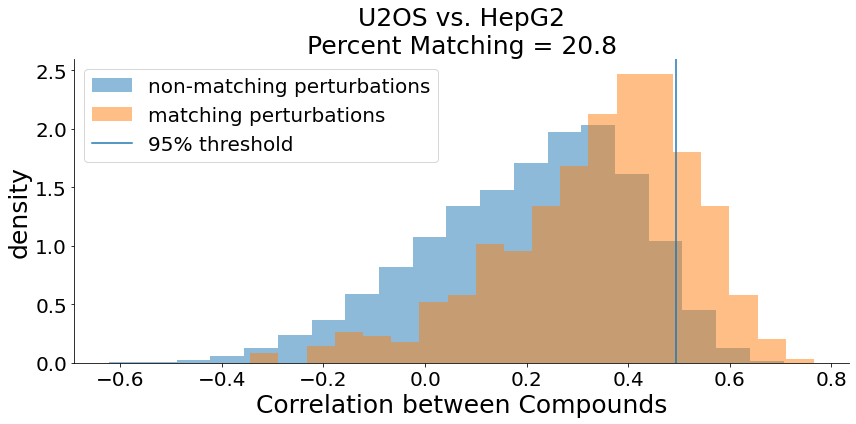

In [24]:
UTIL.distribution_plot(df=corr_df, metric="Percent Matching")

plt.savefig(figure_path + str(date.today()) + "_FMP_U2OS-HepG2_Percent_Pairing.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)

# Compound classes that pair HepG2 - U2OS

In [25]:
# Extract the compounds that have correlation above 95% threshold

list_common_perturbation_groups = list(np.intersect1d(list(data_U2OS_Median['Metadata_EOS']), list(data_HepG2_Median['Metadata_EOS'])))

merged_df = pd.concat([data_U2OS_Median, data_HepG2_Median], ignore_index=False, join='inner')

modality_1_df = merged_df[merged_df['Metadata_Cell_type'] == 'U2OS']
modality_2_df = merged_df[merged_df['Metadata_Cell_type'] == 'HepG2']

corr_modalities = []

for group in list_common_perturbation_groups:
    modality_1_perturbation_df = modality_1_df.loc[modality_1_df['Metadata_EOS'] == group]
    modality_2_perturbation_df = modality_2_df.loc[modality_2_df['Metadata_EOS'] == group]

    for sample_1 in modality_1_perturbation_df['Metadata_EOS_mod'].unique():
        for sample_2 in modality_2_perturbation_df['Metadata_EOS_mod'].unique():
            modality_1_perturbation_sample_df = modality_1_perturbation_df.loc[modality_1_perturbation_df['Metadata_EOS_mod'] == sample_1]
            modality_2_perturbation_sample_df = modality_2_perturbation_df.loc[modality_2_perturbation_df['Metadata_EOS_mod'] == sample_2]

            modality_1_perturbation_profiles = UTIL.get_featuredata(modality_1_perturbation_sample_df)
            modality_2_perturbation_profiles = UTIL.get_featuredata(modality_2_perturbation_sample_df)

            corr = np.corrcoef(modality_1_perturbation_profiles, modality_2_perturbation_profiles)
            corr = corr[0:len(modality_1_perturbation_profiles), len(modality_1_perturbation_profiles):]
            corr_modalities.append(np.nanmedian(corr))  # median replicate correlation

In [26]:
# Create a DataFrame
correlation_U2OS_HepG2 = pd.DataFrame({
    'Metadata_EOS': list_common_perturbation_groups,
    'Correlation': corr_modalities
})

pairing_compounds = correlation_U2OS_HepG2[correlation_U2OS_HepG2['Correlation'] > perc_95]

pairing_compounds.head()

,Metadata_EOS,Correlation
2,EOS100024,0.687916
4,EOS100036,0.654467
6,EOS100040,0.509991
7,EOS100044,0.553257
9,EOS100046,0.586105


In [27]:
# TODO: Compound classes that pair HepG2 - U2OS
# TODO: Get annotations. Analyse the pairing vs non pairing compounds
annotations_broad = pd.read_csv(parent_directory +  "2022-05-13_Labels_Bioactives_Combined_with_Broad_MeSH_JUMP-CP.csv")

In [28]:
# Need the key from pdid to EOS number
pairing_compounds_annot = annotations_broad[annotations_broad['EOS'].isin(pairing_compounds['Metadata_EOS'])]

In [29]:
annotations_pdannotations_pd = pd.read_csv(annot_path  + "pd_export_04_2022_2464_targets_standardized.csv")

In [30]:
pairing_compounds_annot_pd = annotations_pdannotations_pd[annotations_pdannotations_pd['pdid'].isin(pairing_compounds_annot['pdid'])]

In [31]:
unique_targets = pairing_compounds_annot_pd.drop_duplicates(subset=['target_name'])

In [32]:
GTOPDB_numbers = pd.DataFrame(unique_targets['GTOPDB [LEVEL 1]'].value_counts()).reset_index()
Reactome_numbers = pd.DataFrame(unique_targets['Reactome [LEVEL 1]'].value_counts()).reset_index()

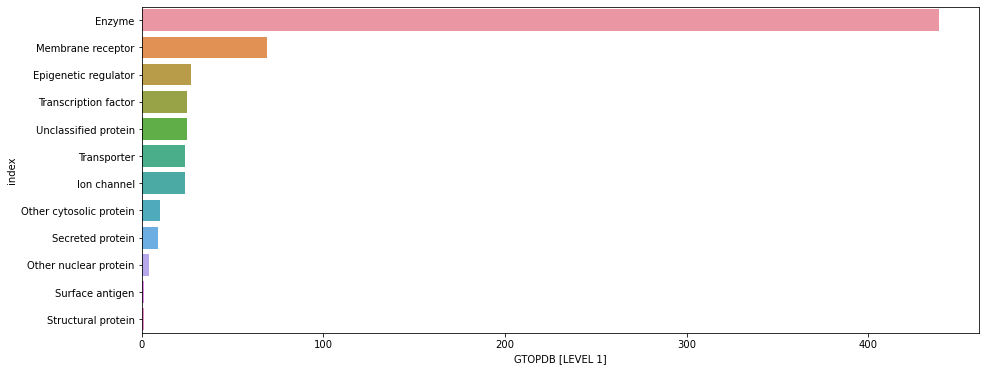

In [33]:
plt.figure(figsize=(15,6))
plot = sns.barplot(data=GTOPDB_numbers , x='GTOPDB [LEVEL 1]', y='index')
# plt.savefig(figure_path + str(date.today()) + '_Bioactives_Targets_GTOPBD.pdf',  dpi=300)

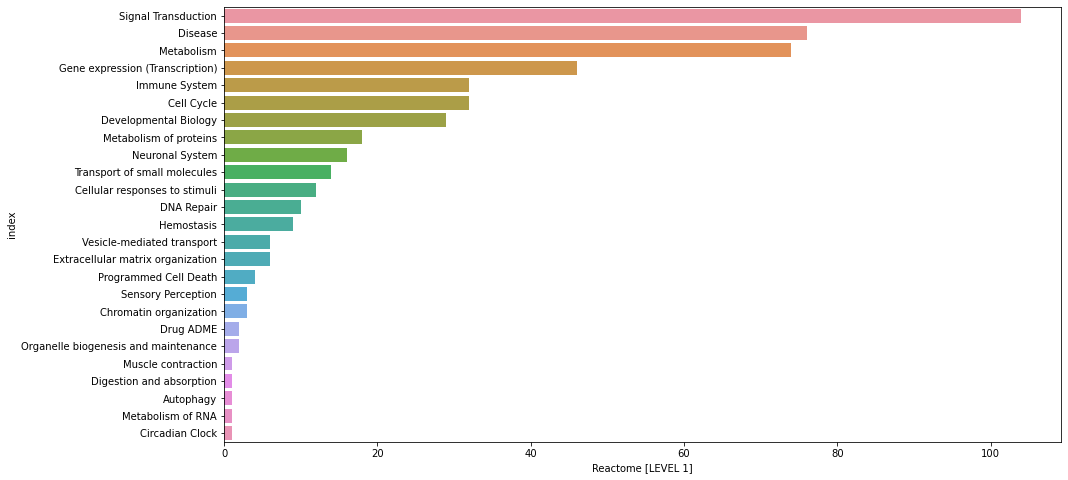

In [34]:
plt.figure(figsize=(15,8))
plot = sns.barplot(data=Reactome_numbers, x='Reactome [LEVEL 1]', y='index')
# plt.savefig(figure_path + str(date.today()) + '_Bioactives_Targets_Reactome.pdf',  dpi=300)

In [35]:
pairing = output_path + str(date.today()) + "_EOS_Pairing_Compouds.csv"
pairing_compounds.to_csv(pairing, index = False)